In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import dask.dataframe as dd

train = dd.read_csv("/Users/abhimanyu/Downloads/train.csv",  names=["target", "review_heading", "review_body"],header=None )
test = dd.read_csv("/Users/abhimanyu/Downloads/test.csv",  names=["target", "review_heading", "review_body"],header=None)

In [4]:
train.tail()

,target,review_heading,review_body
41424,Item Name: ICE BREAKERS Spearmint Sugar Free M...,https://m.media-amazon.com/images/I/81p9PcPsff...,10.395
35537,"Item Name: Davidson's Organics, Vanilla Essenc...",https://m.media-amazon.com/images/I/51DDKoa+mb...,35.92
249971,Item Name: Jolly Rancher Hard Candy - Blue Ras...,https://m.media-amazon.com/images/I/91R2XCcpUf...,50.33
188322,Item Name: Nescafe Dolce Gusto Capsules - CARA...,https://m.media-amazon.com/images/I/51W40YU98+...,15.275
298504,Item Name: Pimenton de la Vera - Picante (2.47...,https://m.media-amazon.com/images/I/81dFnrP6C4...,28.240000000000002


In [5]:
train["review_body"].tail(5).tolist()


['10.395', '35.92', '50.33', '15.275', '28.240000000000002']

In [6]:
# Number of rows
n_rows = len(train)

# Number of columns
n_cols = len(train.columns)

print(f"Rows: {n_rows}, Columns: {n_cols}")


Rows: 75001, Columns: 3


In [7]:
train.isna().sum().compute()

target            0
review_heading    0
review_body       0
dtype: int64

In [8]:
# Replace NaN with "None"
train = train.fillna("None")

# Quick check
train.head()   # shows first 5 rows with NaNs replaced


,target,review_heading,review_body
sample_id,catalog_content,image_link,price
33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.890000000000001
198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.339999999999996


In [9]:
test.isna().sum().compute()

target            0
review_heading    0
review_body       0
dtype: int64

In [10]:
test = test.fillna("None")

In [11]:
dup_count = (train.shape[0] - train.drop_duplicates().shape[0]).compute()
print("Number of duplicate rows:", dup_count)



Number of duplicate rows: 13


In [12]:
import nltk
import re

# Download resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 🔥 IMPORTANT FIX (preload wordnet for Dask)
from nltk.corpus import wordnet
wordnet.ensure_loaded()

# Import after loading
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Precompute (fast)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -----------------------------
# Text cleaning function
# -----------------------------
def transform_text(text):
    if pd.isna(text) or text == "":
        return ""

    text = str(text).lower()

    # Extract words
    words = re.findall(r'\b[a-zA-Z0-9]+\b', text)

    # Lemmatization + stopword removal
    cleaned = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]

    return " ".join(cleaned)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/abhimanyu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/abhimanyu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/abhimanyu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [13]:
train["transformed_review_heading"] = train["review_heading"].apply(
    transform_text, meta=("transformed_review_heading", "str")
)

train["transformed_review_body"] = train["review_body"].apply(
    transform_text, meta=("transformed_review_body", "str")
)

test["transformed_review_heading"] = test["review_heading"].apply(
    transform_text, meta=("transformed_review_heading", "str")
)

test["transformed_review_body"] = test["review_body"].apply(
    transform_text, meta=("transformed_review_body", "str")
)

In [14]:
 test.head()

,target,review_heading,review_body,transformed_review_heading,transformed_review_body
0,sample_id,catalog_content,image_link,,
1,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...,item name rani 14 spice eshamaya mango chutney...,http medium amazon com image 71hoan78awl jpg
2,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...,item name natural milk tea flavoring extract h...,http medium amazon com image 61ex8nhcijl jpg
3,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...,item name honey filled hard candy bulk pack 2 ...,http medium amazon com image 61kcm61j8el jpg
4,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...,item name vlasic snack mm kosher dill 16 oz pa...,http medium amazon com image 51ex6uoh7yl jpg


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter only positive reviews (assuming label column is named 'target' or 'label')
positive_reviews = train[train["target"] == 2]["transformed_review_heading"].astype(str)

# Join all text into one string
text = " ".join(positive_reviews)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Amazon Reviews")
plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.

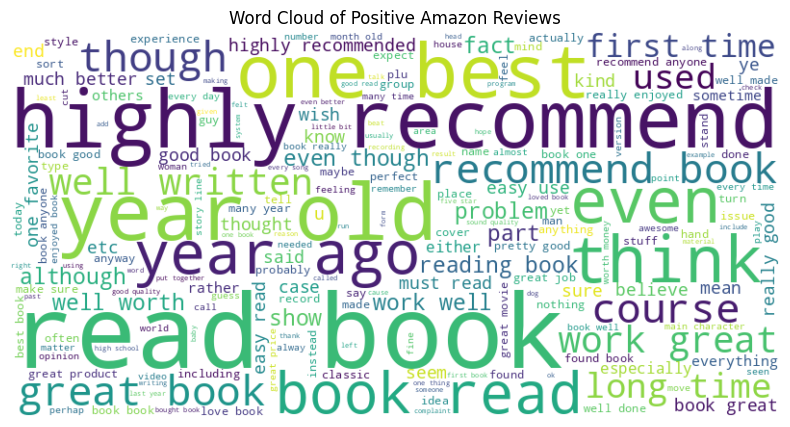

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter only positive reviews (assuming label column is named 'target' or 'label')
positive_reviews = train[train["target"] == 2]["transformed_review_body"].astype(str)

# Join all text into one string
text = " ".join(positive_reviews)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Amazon Reviews")
plt.show()

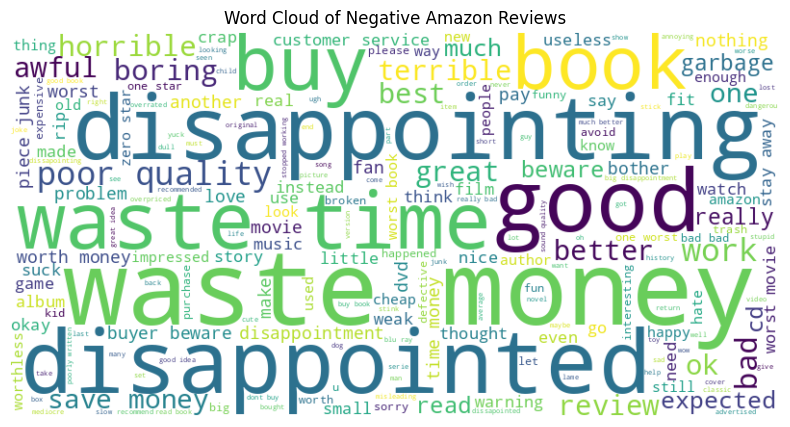

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter only negative reviews (assuming column is named 'target')
negative_reviews = train[train["target"] == 1]["transformed_review_heading"].astype(str)

# Join all text into one string
text = " ".join(negative_reviews)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Amazon Reviews")
plt.show()

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# Filter positive reviews
positive_reviews = train[train["target"] == 2]["transformed_review_heading"].astype(str)

# Vectorize only positive review headings
vectorizer = CountVectorizer(max_features=10, stop_words="english")
X = vectorizer.fit_transform(positive_reviews)

# Get word frequencies
word_freq = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Plot bar chart
sns.barplot(x=word_freq, y=words)
plt.title("Top Words in Positive Reviews")
plt.show()

ValueError: empty vocabulary; perhaps the documents only contain stop words

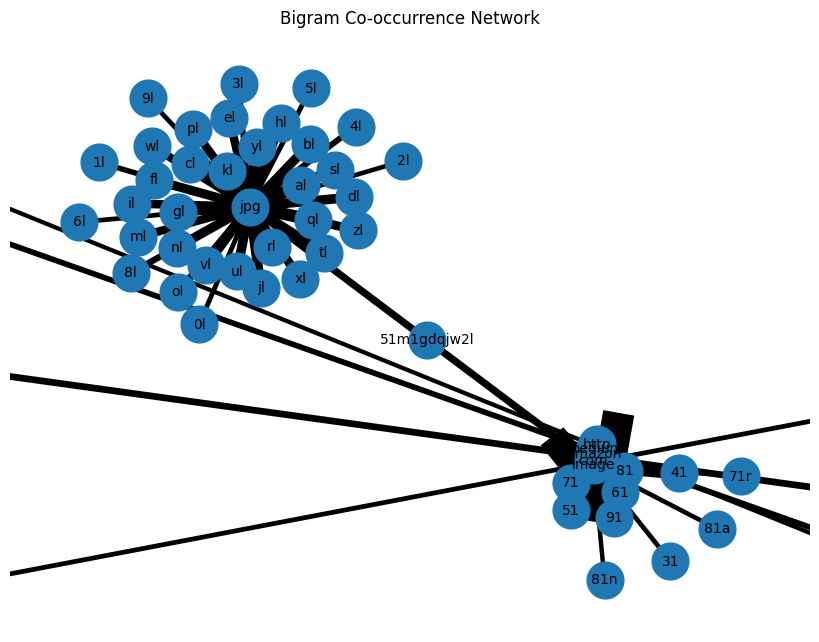

In [17]:
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english", max_features=50)
X = vectorizer.fit_transform(train["transformed_review_heading"].astype(str))
bigrams = vectorizer.get_feature_names_out()
freqs = X.sum(axis=0).A1

# Build graph
G = nx.Graph()
for bigram, freq in zip(bigrams, freqs):
    w1, w2 = bigram.split()
    G.add_edge(w1, w2, weight=freq)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=700, font_size=10, width=[d['weight']/10 for (_,_,d) in G.edges(data=True)])
plt.title("Bigram Co-occurrence Network")
plt.show()

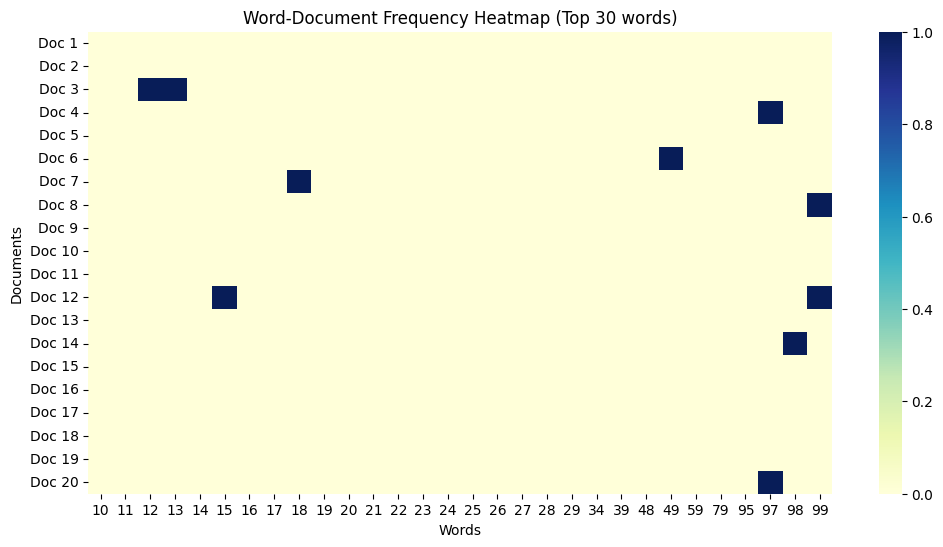

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Vectorize with top 15 words
vectorizer = CountVectorizer(max_features=30, stop_words="english")
X = vectorizer.fit_transform(train["transformed_review_body"].astype(str))

# Convert to array for plotting
matrix = X.toarray()[:20]  # first 20 documents for demo
words = vectorizer.get_feature_names_out()

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(matrix, cmap="YlGnBu", xticklabels=words, yticklabels=[f"Doc {i}" for i in range(1,21)])
plt.title("Word-Document Frequency Heatmap (Top 30 words)")
plt.xlabel("Words")
plt.ylabel("Documents")
plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Positive reviews
# -----------------------------
positive_reviews = train[train["target"] == 2]["transformed_review_heading"].astype(str)
vectorizer_pos = CountVectorizer(max_features=10, stop_words="english")
X_pos = vectorizer_pos.fit_transform(positive_reviews)
word_freq_pos = X_pos.sum(axis=0).A1
words_pos = vectorizer_pos.get_feature_names_out()

# -----------------------------
# Negative reviews
# -----------------------------
negative_reviews = train[train["target"] == 1]["transformed_review_heading"].astype(str)
vectorizer_neg = CountVectorizer(max_features=10, stop_words="english")
X_neg = vectorizer_neg.fit_transform(negative_reviews)
word_freq_neg = X_neg.sum(axis=0).A1
words_neg = vectorizer_neg.get_feature_names_out()

# -----------------------------
# Plot side by side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(x=word_freq_pos, y=words_pos, ax=axes[0], palette="Greens_r")
axes[0].set_title("Top Words in Positive Reviews")

sns.barplot(x=word_freq_neg, y=words_neg, ax=axes[1], palette="Reds_r")
axes[1].set_title("Top Words in Negative Reviews")

plt.tight_layout()
plt.show

ValueError: empty vocabulary; perhaps the documents only contain stop words

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Suppose you have two text columns: 'review_body' and 'review_title'
train_text = train['transformed_review_heading'] + " " + train['transformed_review_body']
test_text = test['transformed_review_heading'] + " " + test['transformed_review_body']

vectorizer = TfidfVectorizer(
    max_features=30000,        # 🔥 increase (not 100x, controlled)
    ngram_range=(1,2),         
    min_df=20,                 # 🔥 increase strongly
    max_df=0.7,                # slight increase
    stop_words='english',
    sublinear_tf=True          # 🔥 very useful for large data
)

X_train = vectorizer.fit_transform(train_text)
X_test = vectorizer.transform(test_text)

In [21]:
y_train = train['target'].replace({2:0})
y_test = test['target'].replace({2:0})

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

params = {'C': 1.1560974175366685, 'solver': 'saga', 'max_iter': 754, 'penalty': 'l2'}

model= LogisticRegression( **params,
    fit_intercept= True, 
    class_weight= 'balanced',
    random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")


ValueError: Floating-point under-/overflow occurred at epoch #1. Scaling input data with StandardScaler or MinMaxScaler might help.

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# Define the TfidfVectorizer parameters (from cell eKZl0HmWMD2p)
tfidf_params = {
    'max_features': 30000,
    'ngram_range': (1, 2),
    'min_df': 20,
    'max_df': 0.7,
    'stop_words': 'english',
    'sublinear_tf': True
}

# Define the LogisticRegression parameters (from cell TcjYySCvMD2r)
logreg_params = {
    'C': 1.1560974175366685,
    'solver': 'saga',
    'max_iter': 754,
    'penalty': 'l2',
    'fit_intercept': True,
    'class_weight': 'balanced',
    'random_state': 42
}

# Build the pipeline without the DaskTextConcatenator step
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('logreg', LogisticRegression(**logreg_params))
])

# Prepare the target variables
# y_train and y_test are already computed in cell NdZjGGIfMD2q
# For the pipeline fit, you will now use the combined and transformed text directly (e.g., train_text.compute())

print("Pipeline created successfully without in-pipeline text transformation!")

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import joblib

# Fit the pipeline
# The input X should be the original Dask DataFrame `train`
pipeline.fit(train_text.compute(), y_train.compute())

# Make predictions on the test set
# The input X should be the original Dask DataFrame `test`
y_pred_pipeline = pipeline.predict(test_text.compute())
y_prob_pipeline = pipeline.predict_proba(test_text.compute())[:, 1]

# Evaluate the pipeline model
print("Pipeline Model Performance:")
print(f"Accuracy: {accuracy_score(y_test.compute(), y_pred_pipeline):.4f}")
print(f"Precision: {precision_score(y_test.compute(), y_pred_pipeline):.4f}")
print(f"Recall: {recall_score(y_test.compute(), y_pred_pipeline):.4f}")
print(f"F1 Score: {f1_score(y_test.compute(), y_pred_pipeline):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test.compute(), y_prob_pipeline):.4f}")

# Export the pipeline
joblib.dump(pipeline, 'text_classification_pipeline.joblib')
print("Pipeline exported successfully as 'text_classification_pipeline.joblib'")

Pipeline created successfully without in-pipeline text transformation!


: 